<a href="https://colab.research.google.com/github/MichaelMcCarey/MovieRecProject/blob/main/movie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Tensorflow library. Used to implement machine learning models
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
#Numpy contains helpful functions for efficient mathematical calculations
import numpy as np
#Dataframe manipulation library
import pandas as pd
#Graph plotting library
import matplotlib.pyplot as plt
%matplotlib inline

import keras
from IPython.display import SVG
from keras.optimizers import Adam
from tensorflow.keras.utils import model_to_dot

from sklearn.metrics import mean_squared_error as MSE,mean_absolute_error
from tabulate import tabulate
from sklearn.model_selection import train_test_split

Instructions for updating:
non-resource variables are not supported in the long term


# Acquiring the Data

In [ ]:
#Loading in the movies dataset
from google.colab import files

uploaded = files.upload()

import zipfile

with zipfile.ZipFile('ml-1m.zip', 'r') as zip_ref:
    zip_ref.extractall('.')
movies_df = pd.read_csv('ml-1m/movies.dat', sep='::', header=None, engine='python',encoding='latin-1')
movies_df.head()

Saving ml-1m.zip to ml-1m.zip


,0,1,2
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


Loading the Data

In [ ]:
# Loading the ratings dataset
ratings_df = pd.read_csv('ml-1m/ratings.dat', sep='::', header=None, engine='python')
ratings_df.head()

,0,1,2,3
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


So our movies_df variable contains a dataframe that stores a movie's unique ID number, title and genres, while our ratings_df variable stores a unique User ID number, a movie's ID that the user has watched, the user's rating to said movie and when the user rated that movie.

Let's now rename the columns in these dataframes so we can better convey their data more intuitively:

In [ ]:
movies_df.columns = ['MovieID', 'Title', 'Genres']
movies_df.head()

,MovieID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


And our final ratings_df:

In [ ]:
ratings_df.columns = ['UserID', 'MovieID', 'Rating', 'Timestamp']
ratings_df.head()

,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


# model

Formatting the Data
First let's see how many movies we have and see if the movie ID's correspond with that value:



In [ ]:
len(movies_df)

3883

In [ ]:
# Train test split
from sklearn.model_selection import train_test_split

# 70% training, 30% temporary
train, temp = train_test_split(
    ratings_df,
    test_size=0.30,
    random_state=42
)

# Split remaining 30% into 20% validation and 10% test
validation, test = train_test_split(
    temp,
    test_size=1/3,
    random_state=42
)

# Save the splits
train.to_csv("train.csv", index=False)
validation.to_csv("validation.csv", index=False)
test.to_csv("test.csv", index=False)
print("Training:", len(train))
print("Validation:", len(validation))
print("Test:", len(test))

from google.colab import files

files.download("train.csv")
files.download("validation.csv")
files.download("test.csv")

Training: 700146
Validation: 200042
Test: 100021


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Now, we can start formatting the data into input for the RBM. We're going to store the normalized users ratings into as a matrix of user-rating called trX, and normalize the values.

In [ ]:
user_rating_df = ratings_df.pivot(index='UserID', columns='MovieID', values='Rating')
user_rating_df.head()

MovieID,1,2,3,4,5,6,7,8,9,10,...,3943,3944,3945,3946,3947,3948,3949,3950,3951,3952
UserID,,,,,,,,,,,,,,,,,,,,,
1,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
user_rating_df[user_rating_df.index==215]

MovieID,1,2,3,4,5,6,7,8,9,10,...,3943,3944,3945,3946,3947,3948,3949,3950,3951,3952
UserID,,,,,,,,,,,,,,,,,,,,,
215,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Lets normalize it now:

In [ ]:
norm_user_rating_df = user_rating_df.fillna(0) / 5.0
trX = norm_user_rating_df.values
trX[0:5]

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
trX[215]
#ratings_df[( ratings_df['UserID']==21)].sort_values(by=['MovieID'],ascending=True)

array([0., 0., 1., ..., 0., 0., 0.])

 RBM

In [ ]:
errors=[]
class RBM(object):
    def __init__(self, input_size, output_size):
        # Defining the hyperparameters
        self._input_size = input_size  # Size of input
        self._output_size = output_size  # Size of output
        self.epochs = 15  # Amount of training iterations
        self.learning_rate = 0.5  # The step used in gradient descent
        self.batchsize = 200  # The size of how much data will be used for training per sub iteration

        # Initializing weights and biases as matrices full of zeroes
        self.w = np.zeros([input_size, output_size], np.float32)  # Creates and initializes the weights with 0
        self.hb = np.zeros([output_size], np.float32)  # Creates and initializes the hidden biases with 0
        self.vb = np.zeros([input_size], np.float32)  # Creates and initializes the visible biases with 0

    # Fits the result from the weighted visible layer plus the bias into a sigmoid curve
    def prob_h_given_v(self, visible, w, hb):
        # Sigmoid
        return tf.nn.sigmoid(tf.matmul(visible, w) + hb)

    # Fits the result from the weighted hidden layer plus the bias into a sigmoid curve
    def prob_v_given_h(self, hidden, w, vb):
        return tf.nn.sigmoid(tf.matmul(hidden, tf.transpose(w)) + vb)

    # Generate the sample probability
    def sample_prob(self, probs):
        return tf.nn.relu(tf.sign(probs - tf.random_uniform(tf.shape(probs))))

    # Training method for the model
    def train(self, X):
        # Create the placeholders for our parameters
        _w = tf.placeholder("float", [self._input_size, self._output_size])
        _hb = tf.placeholder("float", [self._output_size])
        _vb = tf.placeholder("float", [self._input_size])

        prv_w = np.zeros([self._input_size, self._output_size],
                         np.float32)  # Creates and initializes the weights with 0
        prv_hb = np.zeros([self._output_size], np.float32)  # Creates and initializes the hidden biases with 0
        prv_vb = np.zeros([self._input_size], np.float32)  # Creates and initializes the visible biases with 0

        cur_w = np.zeros([self._input_size, self._output_size], np.float32)
        cur_hb = np.zeros([self._output_size], np.float32)
        cur_vb = np.zeros([self._input_size], np.float32)
        v0 = tf.placeholder("float", [None, self._input_size])

        # Initialize with sample probabilities
        h0 = self.sample_prob(self.prob_h_given_v(v0, _w, _hb))
        v1 = self.sample_prob(self.prob_v_given_h(h0, _w, _vb))
        h1 = self.prob_h_given_v(v1, _w, _hb)

        # Create the Gradients
        positive_grad = tf.matmul(tf.transpose(v0), h0)
        negative_grad = tf.matmul(tf.transpose(v1), h1)

        # Update learning rates for the layers
        update_w = _w + self.learning_rate * (positive_grad - negative_grad) / tf.to_float(tf.shape(v0)[0])
        update_vb = _vb + self.learning_rate * tf.reduce_mean(v0 - v1, 0)
        update_hb = _hb + self.learning_rate * tf.reduce_mean(h0 - h1, 0)

        # Find the error rate
        err = tf.reduce_mean(tf.square(v0 - v1))

        # Training loop
        with tf.Session() as sess:
            sess.run(tf.global_variables_initializer())
            # For each epoch
            for epoch in range(self.epochs):
                # For each step/batch
                for start, end in zip(range(0, len(X), self.batchsize), range(self.batchsize, len(X), self.batchsize)):
                    batch = X[start:end]
                    # Update the rates
                    cur_w = sess.run(update_w, feed_dict={v0: batch, _w: prv_w, _hb: prv_hb, _vb: prv_vb})
                    cur_hb = sess.run(update_hb, feed_dict={v0: batch, _w: prv_w, _hb: prv_hb, _vb: prv_vb})
                    cur_vb = sess.run(update_vb, feed_dict={v0: batch, _w: prv_w, _hb: prv_hb, _vb: prv_vb})
                    prv_w = cur_w
                    prv_hb = cur_hb
                    prv_vb = cur_vb
                error = sess.run(err, feed_dict={v0: X, _w: cur_w, _vb: cur_vb, _hb: cur_hb})
                print('Epoch: %d' % epoch, 'reconstruction error: %f' % error)
                errors.append(error)
            self.w = prv_w
            self.hb = prv_hb
            self.vb = prv_vb

    # Create expected output for our DBN
    def rbm_outpt(self, X):
#         X=tf.cast(X,tf.float32)
        input_X = tf.constant(X)
        input_X=tf.cast(input_X,tf.float32)
        _w = tf.constant(self.w)
        _w=tf.cast(_w,tf.float32)
        _hb = tf.constant(self.hb)
#         out = tf.nn.sigmoid(tf.matmul(input_X, _w) + _hb)
        out=tf.nn.softmax(tf.matmul(input_X, _w) + _hb)
        with tf.Session() as sess:
            sess.run(tf.global_variables_initializer())
            return sess.run(out)




DBM

In [ ]:
RBM_hidden_sizes = [1500, 700 , 50 ] #create 4 layers of RBM with size 785-500-200-50

#Since we are training, set input as training data
inpX = trX

#Create list to hold our RBMs
rbm_list = []

#Size of inputs is the number of inputs in the training set
input_size = inpX.shape[1]

#For each RBM we want to generate
for i, size in enumerate(RBM_hidden_sizes):
    print('RBM: ',i,' ',input_size,'->', size)
    rbm_list.append(RBM(input_size, size))
    input_size = size

RBM:  0   3706 -> 1500
RBM:  1   1500 -> 700
RBM:  2   700 -> 50


train


New RBM:
Epoch: 0 reconstruction error: 0.098608
Epoch: 1 reconstruction error: 0.072704
Epoch: 2 reconstruction error: 0.063448
Epoch: 3 reconstruction error: 0.058765
Epoch: 4 reconstruction error: 0.054308
Epoch: 5 reconstruction error: 0.050824
Epoch: 6 reconstruction error: 0.049243
Epoch: 7 reconstruction error: 0.048310
Epoch: 8 reconstruction error: 0.047470
Epoch: 9 reconstruction error: 0.046670
Epoch: 10 reconstruction error: 0.045961
Epoch: 11 reconstruction error: 0.045487
Epoch: 12 reconstruction error: 0.045114
Epoch: 13 reconstruction error: 0.044537
Epoch: 14 reconstruction error: 0.044310
New RBM:
Epoch: 0 reconstruction error: 0.001031
Epoch: 1 reconstruction error: 0.000638
Epoch: 2 reconstruction error: 0.000994
Epoch: 3 reconstruction error: 0.000877
Epoch: 4 reconstruction error: 0.001035
Epoch: 5 reconstruction error: 0.001042
Epoch: 6 reconstruction error: 0.000909
Epoch: 7 reconstruction error: 0.001078
Epoch: 8 reconstruction error: 0.000780
Epoch: 9 reconstr

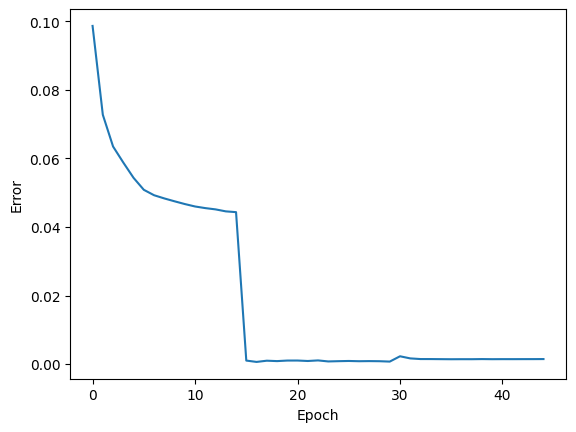

In [ ]:
#For each RBM in our list
for rbm in rbm_list:
    print('New RBM:')
    #Train a new one
    rbm.train(inpX)
    #Return the output layer
    inpX = rbm.rbm_outpt(inpX)
plt.plot(errors)
plt.ylabel('Error')
plt.xlabel('Epoch')
plt.show()

Recommendation

In [ ]:
mock_user_id = 215

In [ ]:
#Selecting the input user
inputUser = trX[mock_user_id-1].reshape(1, -1)
inputUser[0:5]

array([[0.8, 0. , 0. , ..., 0. , 0. , 0. ]])

In [ ]:
hiddenNodes = 20
visibleNodes =  len(user_rating_df.columns)
#Number of unique movies
visibleBias = tf.placeholder("float", [visibleNodes])
#Number of features we're going to learn
hiddenBias = tf.placeholder("float", [hiddenNodes])
# Weight Matrix
W = tf.placeholder("float", [visibleNodes, hiddenNodes])


#Phase 1: Input Processing
visible_0 = tf.placeholder("float", [None, visibleNodes])
_hidden_0 = tf.nn.sigmoid(tf.matmul(visible_0, W) + hiddenBias)
hidden_0 = tf.nn.relu(tf.sign(_hidden_0 - tf.random_uniform(tf.shape(_hidden_0))))
#Phase 2: Reconstruction
_v1 = tf.nn.sigmoid(tf.matmul(hidden_0, tf.transpose(W)) + visibleBias)
visible_1 = tf.nn.relu(tf.sign(_v1 - tf.random_uniform(tf.shape(_v1))))
hidden_1 = tf.nn.sigmoid(tf.matmul(visible_1, W) + hiddenBias)

#Learning rate
alpha = 0.5
#Create the gradients
w_pos_grad = tf.matmul(tf.transpose(visible_0), hidden_0)
w_neg_grad = tf.matmul(tf.transpose(visible_1), hidden_1)
#Calculate the Contrastive Divergence to maximize
CD = (w_pos_grad - w_neg_grad) / tf.to_float(tf.shape(visible_0)[0])
#Create methods to update the weights and biases
update_weight = W + alpha * CD
update_vb = visibleBias + alpha * tf.reduce_mean(visible_0 - visible_1, 0)
update_hb = hiddenBias + alpha * tf.reduce_mean(hidden_0 - hidden_1, 0)

#Feeding in the user and reconstructing the input


sess = tf.Session()

#Current weight
current_weight = np.zeros([visibleNodes, hiddenNodes], np.float32)
#Current visible unit biases
current_vb = np.zeros([visibleNodes], np.float32)
#Current hidden unit biases
current_hb = np.zeros([hiddenNodes], np.float32)
#Previous weight
previous_weight = np.zeros([visibleNodes, hiddenNodes], np.float32)
#Previous visible unit biases
previous_vb = np.zeros([visibleNodes], np.float32)
#Previous hidden unit biases
previous_hb = np.zeros([hiddenNodes], np.float32)
sess = tf.Session()
sess.run(tf.global_variables_initializer())


err = visible_0 - visible_1
err_sum = tf.reduce_mean(err * err)

epochs = 15
batchsize = 200
errors = []
for i in range(epochs):
    for start, end in zip( range(0, len(trX), batchsize), range(batchsize, len(trX), batchsize)):
        batch = trX[start:end]
        current_weight = sess.run(update_weight, feed_dict={visible_0: batch, W: previous_weight, visibleBias: previous_vb, hiddenBias: previous_hb})
        current_vb = sess.run(update_vb, feed_dict={visible_0: batch, W: previous_weight, visibleBias: previous_vb, hiddenBias: previous_hb})
        cur_nb = sess.run(update_hb, feed_dict={visible_0: batch, W: previous_weight, visibleBias: previous_vb, hiddenBias: previous_hb})
        previous_weight = current_weight
        previous_vb = current_vb
        previous_hb = current_hb
    errors.append(sess.run(err_sum, feed_dict={visible_0: trX, W: current_weight, visibleBias: current_vb, hiddenBias: current_hb}))

# hidden_0 = RBM.prob_h_given_v()
# vv1 = RBM.prob_v_given_h
hidden_0 = tf.nn.sigmoid(tf.matmul(visible_0, W) + hiddenBias)
vv1 = tf.nn.softmax(tf.matmul(hidden_0, tf.transpose(W)) + visibleBias)

feed = sess.run(hidden_0, feed_dict={ visible_0: inputUser, W: previous_weight, hiddenBias: previous_hb})
rec = sess.run(vv1, feed_dict={ hidden_0: feed, W: previous_weight, visibleBias: previous_vb})
print(rec)

[[5.0714873e-03 1.0351196e-03 2.3537484e-04 ... 9.3986209e-06
  5.5028681e-06 8.0732258e-05]]


In [ ]:
scored_movies_df_mock = movies_df[movies_df['MovieID'].isin(user_rating_df.columns)]
scored_movies_df_mock = scored_movies_df_mock.assign(RecommendationScore = rec[0])
scored_movies_df_mock.sort_values(["RecommendationScore"], ascending=False).head(20)

,MovieID,Title,Genres,RecommendationScore
257,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Fantasy|Sci-Fi,0.161975
1178,1196,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Drama|Sci-Fi|War,0.049804
2502,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,0.044117
585,589,Terminator 2: Judgment Day (1991),Action|Sci-Fi|Thriller,0.036205
1192,1210,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Romance|Sci-Fi|War,0.035080
1539,1580,Men in Black (1997),Action|Adventure|Comedy|Sci-Fi,0.033774
476,480,Jurassic Park (1993),Action|Adventure|Sci-Fi,0.024312
2559,2628,Star Wars: Episode I - The Phantom Menace (1999),Action|Adventure|Fantasy|Sci-Fi,0.022712
1081,1097,E.T. the Extra-Terrestrial (1982),Children's|Drama|Fantasy|Sci-Fi,0.010150
1250,1270,Back to the Future (1985),Comedy|Sci-Fi,0.010067


In [ ]:
movies_df_mock = ratings_df[ratings_df['UserID'] == mock_user_id]
movies_df_mock.head()

,UserID,MovieID,Rating,Timestamp
31603,215,3793,5,977099259
31604,215,1,4,979174987
31605,215,1197,5,976899663
31606,215,2302,5,976899718
31607,215,2167,5,976899770


In [ ]:
#Merging movies_df with ratings_df by MovieID
merged_df_mock = scored_movies_df_mock.merge(movies_df_mock, on='MovieID', how='outer')

In [ ]:
merged_df_mock.sort_values(["RecommendationScore"], ascending=False).head(20)

,MovieID,Title,Genres,RecommendationScore,UserID,Rating,Timestamp
253,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Fantasy|Sci-Fi,0.161975,215.0,5.0,976899190.0
1106,1196,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Drama|Sci-Fi|War,0.049804,NaN,NaN,NaN
2374,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,0.044117,NaN,NaN,NaN
575,589,Terminator 2: Judgment Day (1991),Action|Sci-Fi|Thriller,0.036205,NaN,NaN,NaN
1120,1210,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Romance|Sci-Fi|War,0.035080,215.0,5.0,976899689.0
1449,1580,Men in Black (1997),Action|Adventure|Comedy|Sci-Fi,0.033774,NaN,NaN,NaN
466,480,Jurassic Park (1993),Action|Adventure|Sci-Fi,0.024312,215.0,5.0,976899784.0
2426,2628,Star Wars: Episode I - The Phantom Menace (1999),Action|Adventure|Fantasy|Sci-Fi,0.022712,215.0,5.0,976908635.0
1025,1097,E.T. the Extra-Terrestrial (1982),Children's|Drama|Fantasy|Sci-Fi,0.010150,215.0,5.0,976908468.0
1178,1270,Back to the Future (1985),Comedy|Sci-Fi,0.010067,NaN,NaN,NaN


In [ ]:
header_Cl = ["Model" , "Mean Absoulte Error"]
table_cl  = [
        ["DBM",0.000405],
        ["RBM",'0.0449'],
        ["Autoencoders",'3.37'],
        ["SVD",'0.218 with bias and 0.064 without bias'],
        ["SVD++",'0.744'],
        ["DNN with Keras",'0.69'],
            ]
print(tabulate(table_cl, header_Cl, tablefmt="fancy_grid"))

╒════════════════╤════════════════════════════════════════╕
│ Model          │ Mean Absoulte Error                    │
╞════════════════╪════════════════════════════════════════╡
│ DBM            │ 0.000405                               │
├────────────────┼────────────────────────────────────────┤
│ RBM            │ 0.0449                                 │
├────────────────┼────────────────────────────────────────┤
│ Autoencoders   │ 3.37                                   │
├────────────────┼────────────────────────────────────────┤
│ SVD            │ 0.218 with bias and 0.064 without bias │
├────────────────┼────────────────────────────────────────┤
│ SVD++          │ 0.744                                  │
├────────────────┼────────────────────────────────────────┤
│ DNN with Keras │ 0.69                                   │
╘════════════════╧════════════════════════════════════════╛


In [ ]:
mer1=merged_df_mock.sort_values(["RecommendationScore"], ascending=False)

In [ ]:
mer2=mer1.fillna(0)

In [ ]:
mer2

,MovieID,Title,Genres,RecommendationScore,UserID,Rating,Timestamp
253,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Fantasy|Sci-Fi,0.161975,215.0,5.0,976899190.0
1106,1196,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Drama|Sci-Fi|War,0.049804,0.0,0.0,0.0
2374,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,0.044117,0.0,0.0,0.0
575,589,Terminator 2: Judgment Day (1991),Action|Sci-Fi|Thriller,0.036205,0.0,0.0,0.0
1120,1210,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Romance|Sci-Fi|War,0.035080,215.0,5.0,976899689.0
...,...,...,...,...,...,...,...
650,672,Tarantella (1995),Drama,0.000002,0.0,0.0,0.0
707,744,Brothers in Trouble (1995),Drama,0.000002,0.0,0.0,0.0
3176,3407,"Carriers Are Waiting, The (Les Convoyeurs Atte...",Comedy|Drama,0.000002,0.0,0.0,0.0
1612,1773,Tokyo Fist (1995),Action|Drama,0.000002,0.0,0.0,0.0


In [ ]:
mer3=mer2[mer2['Timestamp']==0]

In [ ]:
mer3

,MovieID,Title,Genres,RecommendationScore,UserID,Rating,Timestamp
1106,1196,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Drama|Sci-Fi|War,0.049804,0.0,0.0,0.0
2374,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,0.044117,0.0,0.0,0.0
575,589,Terminator 2: Judgment Day (1991),Action|Sci-Fi|Thriller,0.036205,0.0,0.0,0.0
1449,1580,Men in Black (1997),Action|Adventure|Comedy|Sci-Fi,0.033774,0.0,0.0,0.0
1178,1270,Back to the Future (1985),Comedy|Sci-Fi,0.010067,0.0,0.0,0.0
...,...,...,...,...,...,...,...
650,672,Tarantella (1995),Drama,0.000002,0.0,0.0,0.0
707,744,Brothers in Trouble (1995),Drama,0.000002,0.0,0.0,0.0
3176,3407,"Carriers Are Waiting, The (Les Convoyeurs Atte...",Comedy|Drama,0.000002,0.0,0.0,0.0
1612,1773,Tokyo Fist (1995),Action|Drama,0.000002,0.0,0.0,0.0


In [ ]:
mer3.sort_values(["RecommendationScore"], ascending=False).head(20)

,MovieID,Title,Genres,RecommendationScore,UserID,Rating,Timestamp
1106,1196,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Drama|Sci-Fi|War,0.049804,0.0,0.0,0.0
2374,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,0.044117,0.0,0.0,0.0
575,589,Terminator 2: Judgment Day (1991),Action|Sci-Fi|Thriller,0.036205,0.0,0.0,0.0
1449,1580,Men in Black (1997),Action|Adventure|Comedy|Sci-Fi,0.033774,0.0,0.0,0.0
1178,1270,Back to the Future (1985),Comedy|Sci-Fi,0.010067,0.0,0.0,0.0
1148,1240,"Terminator, The (1984)",Action|Sci-Fi|Thriller,0.009245,0.0,0.0,0.0
737,780,Independence Day (ID4) (1996),Action|Sci-Fi|War,0.009110,0.0,0.0,0.0
1258,1356,Star Trek: First Contact (1996),Action|Adventure|Sci-Fi,0.008213,0.0,0.0,0.0
1108,1198,Raiders of the Lost Ark (1981),Action|Adventure,0.007671,0.0,0.0,0.0
1124,1214,Alien (1979),Action|Horror|Sci-Fi|Thriller,0.006249,0.0,0.0,0.0
